# PseudoVelo Case 3 - Comprehensive Evaluation and Robustness Analysis

In [1]:
import warnings, sys, os
import logging

def customwarn(message, category, filename, lineno, file=None, line=None):
    pass
warnings.showwarning = customwarn
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="No data for colormapping provided via 'c'.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger().setLevel(logging.ERROR) 
os.environ['PYTHONWARNINGS'] = 'ignore'

import scanpy as sc
sc.settings.verbosity = 0 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pseudovelo as pv
import cellrank as cr
import scvelo as scv
from cellmapper import CellMapper
from cellrank.kernels import CytoTRACEKernel
from transition import evaluate_transition_accuracy, projection_consistency

np.random.seed(0)

In [2]:
def plot_projection_consistency_boxplot(data, labels=None):
    plt.figure(figsize=(2.5, 2.5))
    if isinstance(data, pd.Series) or (isinstance(data, np.ndarray) and data.ndim == 1):
        data = [data]
    
    sns.boxplot(data=data, width=0.2, palette="Set2", fliersize=2)
    for i, d in enumerate(data):
        plt.text(i + 0.15, np.nanmedian(d), f'{np.nanmedian(d):.2f}', ha='left', va='center', fontsize=8)
    
    plt.ylabel('Projection Consistency', fontsize=10)
    if labels is not None:
        plt.xticks(range(len(labels)), labels, fontsize=10)
    else:
        plt.xticks(fontsize=10, rotation=15)
    sns.despine()
    plt.tight_layout()
    plt.show()

def load_and_preprocess_data(subsample_cells=False, subsample_genes=False):
    adata = sc.read_h5ad("./data/pancreas/endocrinogenesis_day15.h5ad")
    
    if subsample_cells:
        sc.pp.subsample(adata, fraction=0.5)
    if subsample_genes:
        adata = adata[:, np.random.choice(adata.n_vars, size=adata.n_vars // 2, replace=False)].copy()
        
    sc.pp.filter_genes(adata, min_cells=10)
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata = adata[:, adata.var.highly_variable].copy()
    sc.tl.pca(adata)
    sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
    return adata

def find_root_index(adata, col_name, val):
    # Specific logic for Pancreas dataset: max Y-coordinate on UMAP for root cluster
    idx = np.where(adata.obs[col_name] == val)[0]
    return idx[np.argmax(adata.obsm["X_umap"][idx, 1])]

def run_eval_pipeline(adata, time_key="dpt_pseudotime", cluster_key="clusters", run_dpt=True, root_idx=None, ctk=None, n_states_cr2=5, n_states_pv=5):
    
    # 1. DPT Root
    if run_dpt and root_idx is not None:
        adata.uns["iroot"] = root_idx
        sc.tl.diffmap(adata)
        sc.tl.dpt(adata)
        fig, ax = plt.subplots(figsize=(3.7,3))
        sc.pl.embedding(adata, color="dpt_pseudotime", show=False, basis="umap", ax=ax, frameon=False, size=15)
        start_x, start_y = adata.obsm["X_umap"][root_idx, 0], adata.obsm["X_umap"][root_idx, 1]
        plt.scatter(start_x, start_y, color='red', marker='*', s=200, edgecolors='black', zorder=5)
        plt.show()

    # 2. PseudoVelo
    adata.layers["X"] = adata.X.toarray()
    pv.fit_nb_gam_with_center_diff(adata, J_key=time_key, n_jobs=10, cluster_key=cluster_key, input_layer="X", reverse=False, output_layer="gam_X", dmu_layer="gam_X_J")
    pv.plot_velocity_projection(adata, xkey="X", vkey="gam_X_J", basis="umap", color="clusters", 
                                figsize=(3.9,3.1), title="PseudoVelo", size=120, legend_loc="none")

    # 3. CellRank2
    if time_key == "dpt_pseudotime":
        kernel = cr.kernels.PseudotimeKernel(adata, time_key=time_key)
        kernel.compute_transition_matrix()
        kernel.write_to_adata()
        
        kernel.plot_projection(basis="umap", color="clusters", show=False, figsize=(3.9,3.1), 
                            title="CellRank2", s=120, legend_fontsize=8, legend_loc="none")
        plt.gca().grid(False)
        plt.show()
    else:
        kernel = ctk

    # 4. Quantitative Analysis 1: Consistency
    c_pv = projection_consistency(adata, embedding_key='X_umap', vkey='gam_X_J', l2_norm=False)
    c_cr2 = projection_consistency(adata, embedding_key='X_umap', l2_norm=False, T_velo=kernel.transition_matrix)
    adata.obs[f'consistency_{time_key}_pv'] = c_pv
    adata.obs[f'consistency_{time_key}_cr2'] = c_cr2
    plot_projection_consistency_boxplot([c_pv, c_cr2], labels=["PseudoVelo", "CellRank2"])

    # 5. Quantitative Analysis 2: Transition Accuracy
    order = [['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine','Beta'], 
             ['Pre-endocrine', 'Alpha'], 
             ['Pre-endocrine','Delta'], 
             ['Pre-endocrine','Epsilon']]
    acc_pv = evaluate_transition_accuracy(adata, cluster_key="clusters", lineage_order=order, vkey='gam_X_J')
    acc_cr2 = evaluate_transition_accuracy(adata, cluster_key="clusters", lineage_order=order, T=kernel.transition_matrix)
    print(f"{time_key} - pv accuracy:", acc_pv)
    print(f"{time_key} - cr2 accuracy:", acc_cr2)

    # 6. GPCCA Analysis
    g_cr2 = cr.estimators.GPCCA(kernel)
    g_cr2.compute_macrostates(cluster_key="clusters", n_states=n_states_cr2)
    g_cr2.predict_initial_states()
    g_cr2.predict_terminal_states(allow_overlap=True)
    g_cr2.plot_macrostates(which="initial", legend_loc="on data", s=100, basis="umap", figsize=(4,4))
    g_cr2.plot_macrostates(which="terminal", legend_loc="on data", s=100, basis="umap", figsize=(4,4))

    vk = cr.kernels.VelocityKernel(adata, vkey="gam_X_J", xkey="X")
    vk.compute_transition_matrix()
    g_pv = cr.estimators.GPCCA(vk)
    g_pv.compute_macrostates(n_states=n_states_pv, cluster_key="clusters")
    g_pv.predict_initial_states()
    g_pv.predict_terminal_states(allow_overlap=True)
    g_pv.plot_macrostates(which="initial", legend_loc="on data", s=100, basis="umap", figsize=(4,4))
    g_pv.plot_macrostates(which="terminal", legend_loc="on data", s=100, basis="umap", figsize=(4,4))
    
    return adata, kernel

### Part 1: Standard Evaluation and CytoTRACE Comparison

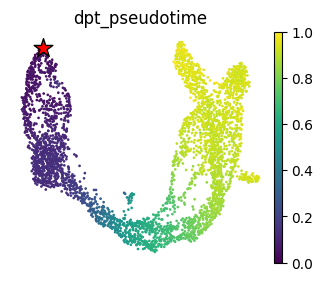

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'clusters', n_clusters = 8
[cluster=Ductal] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.168), n_jobs = 10.
[cluster=Ngn3 low EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 5 (factor = 0.417), n_jobs = 10.
[cluster=Ngn3 high EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 6 (factor = 0.598), n_jobs = 10.
[cluster=Pre-endocrine] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.28), n_jobs = 10.
[cluster=Beta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.141), n_jobs = 10.
[cluster=Alpha] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.171), n_jobs = 10.
[cluster=Delta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0638), n_jobs = 10.
[cluster=Epsilon] Fitting NB GLMGam for 2000 genes (ce

  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


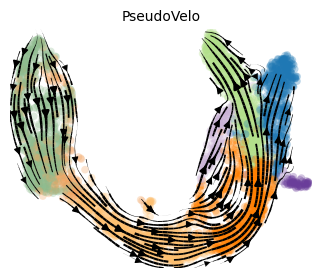

computing velocity embedding
finished.


  0%|          | 0/3696 [00:00<?, ?cell/s]

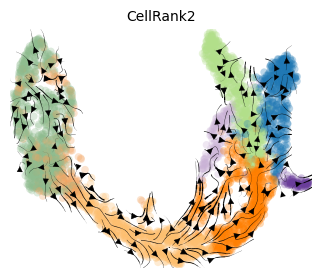

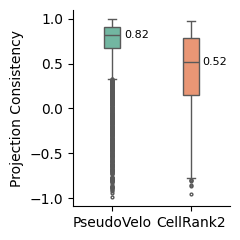

dpt_pseudotime - pv accuracy: 0.63069034
dpt_pseudotime - cr2 accuracy: 0.5347796562264112


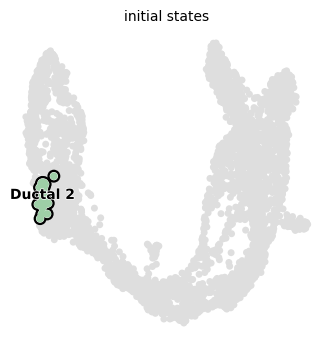

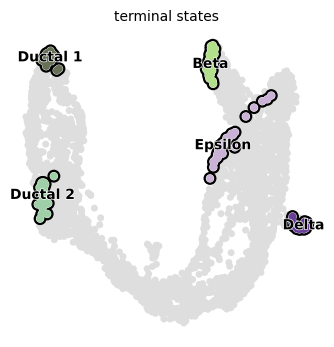

  0%|          | 0/3696 [00:00<?, ?cell/s]

  0%|          | 0/3696 [00:00<?, ?cell/s]

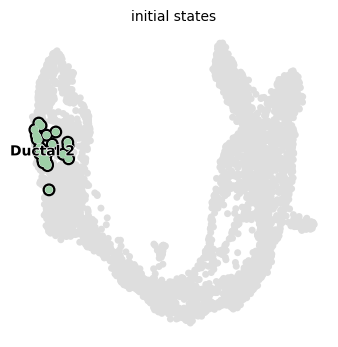

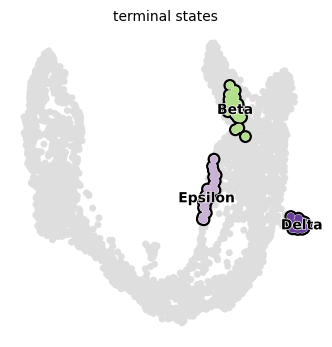

In [3]:
# 1.1 DPT Standard
adata_dpt = load_and_preprocess_data()
root_idx = find_root_index(adata_dpt, "clusters", "Ductal")
adata_dpt, pk = run_eval_pipeline(adata_dpt, time_key="dpt_pseudotime", cluster_key="clusters", root_idx=root_idx)

INFO     Initialized CellMapper for self-mapping with 3696 cells.                                                  
INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using kernel method 'umap'.                                                      
INFO     Mapping layer for key 'X' using direct multiplication                                                     
INFO     Imputed expression matrix with shape (3696, 13821) converted to AnnData object.                           
         Observation metadata from query and feature metadata from reference were linked (not copied).             
INFO     Expression for layer 'X' mapped and stored in query_imputed.X. 

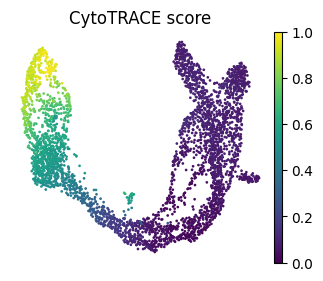

  0%|          | 0/3696 [00:00<?, ?cell/s]

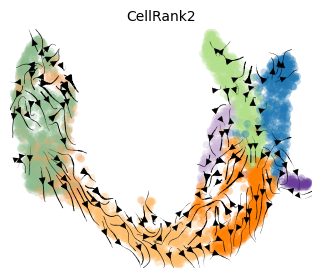

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'clusters', n_clusters = 8
[cluster=Ductal] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 6 (factor = 0.596), n_jobs = 10.
[cluster=Ngn3 low EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 7 (factor = 0.608), n_jobs = 10.
[cluster=Ngn3 high EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 7 (factor = 0.604), n_jobs = 10.
[cluster=Pre-endocrine] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.284), n_jobs = 10.
[cluster=Beta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0589), n_jobs = 10.
[cluster=Alpha] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.16), n_jobs = 10.
[cluster=Delta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.053), n_jobs = 10.
[cluster=Epsilon] Fitting NB GLMGam for 2000 genes (ce

  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


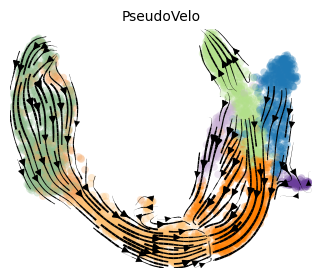

computing velocity embedding
finished.


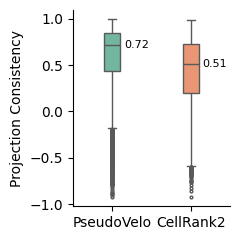

ct_pseudotime - pv accuracy: 0.4047591
ct_pseudotime - cr2 accuracy: 0.5048951051312308


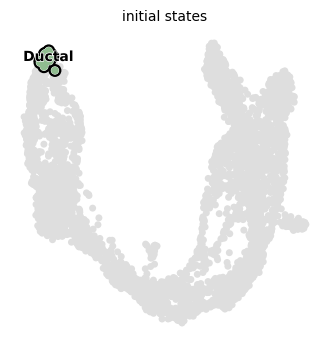

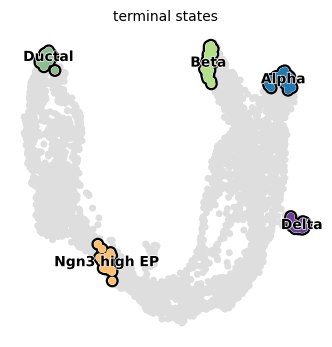

  0%|          | 0/3696 [00:00<?, ?cell/s]

  0%|          | 0/3696 [00:00<?, ?cell/s]

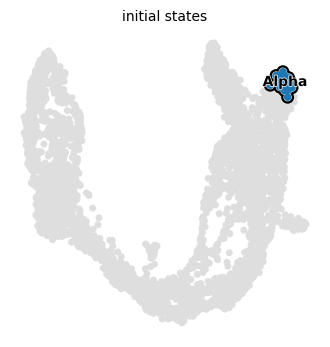

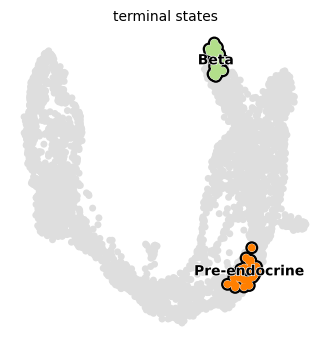

In [4]:
# 1.2 CytoTRACE Analysis
adata_raw = sc.read_h5ad("./data/pancreas/endocrinogenesis_day15.h5ad")
adata_ct = adata_raw.copy()

sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct, n_top_genes=2000)
sc.tl.pca(adata_ct)
sc.pp.neighbors(adata_ct, n_neighbors=30, n_pcs=30)

adata_ct.layers["imputed"] = CellMapper(adata_ct).map(layer_key="X", use_rep="X_pca").query_imputed.X.copy()
ctk = CytoTRACEKernel(adata_ct).compute_cytotrace(layer="imputed")
adata_ct.obs["1_minus_pseudotime"] = 1 - adata_ct.obs["ct_pseudotime"]

fig, ax = plt.subplots(figsize=(3.7,3))
sc.pl.embedding(adata_ct, basis="umap", color="1_minus_pseudotime", frameon=False, ax=ax, size=15, title="CytoTRACE score", legend_fontsize=8)
ctk.compute_transition_matrix()
ctk.plot_projection(basis="umap", color="clusters", figsize=(3.9,3.1), title="CellRank2", size=120, legend_loc="none", show=False)
ax = plt.gca()
ax.grid(False)
plt.show()

# Build adata for PV (align genes and parameters)
adata_pv_ct = load_and_preprocess_data()
adata_pv_ct.obs["ct_pseudotime"] = adata_ct.obs["ct_pseudotime"]
adata_pv_ct, ctk = run_eval_pipeline(adata_pv_ct, time_key="ct_pseudotime", cluster_key="clusters", run_dpt=False, ctk=ctk, n_states_cr2=5, n_states_pv=5)


### Part 2: Robustness Analysis
Test the impact of re-clustering, cell subsampling, and gene subsampling on the results.


--- Running Robustness: Re-clustering (Leiden) ---


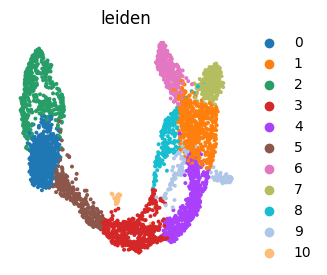

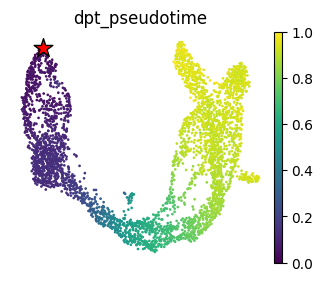

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'leiden', n_clusters = 11
[cluster=0] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0876), n_jobs = 10.
[cluster=1] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.105), n_jobs = 10.
[cluster=2] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.173), n_jobs = 10.
[cluster=3] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.322), n_jobs = 10.
[cluster=4] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.201), n_jobs = 10.
[cluster=5] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.351), n_jobs = 10.
[cluster=6] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.111), n_jobs = 10.
[cluster=7] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0955), n_job

  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


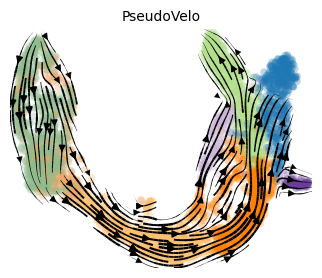

computing velocity embedding
finished.


  0%|          | 0/3696 [00:00<?, ?cell/s]

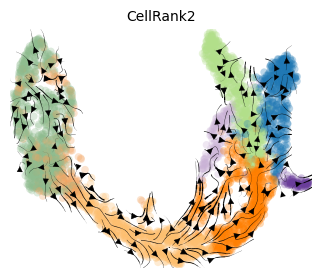

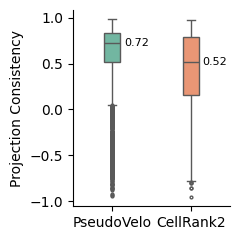

dpt_pseudotime - pv accuracy: 0.651454
dpt_pseudotime - cr2 accuracy: 0.5347796562264112


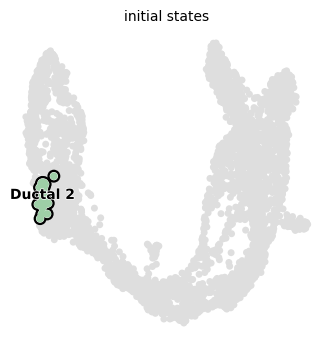

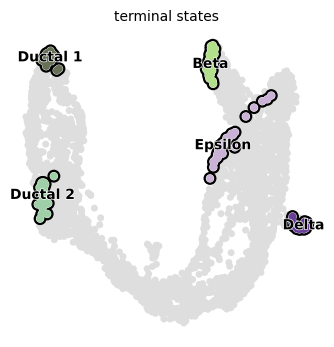

  0%|          | 0/3696 [00:00<?, ?cell/s]

  0%|          | 0/3696 [00:00<?, ?cell/s]

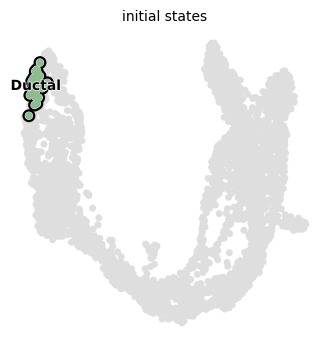

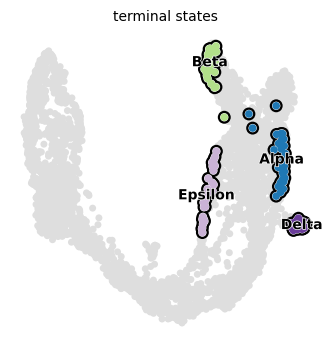

In [5]:
# 2.1 Re-clustering Test (Leiden resolution 0.8)
print("\n--- Running Robustness: Re-clustering (Leiden) ---")
adata_rob_cluster = load_and_preprocess_data()
sc.tl.leiden(adata_rob_cluster, resolution=0.8)

fig, ax = plt.subplots(figsize=(3,3))
sc.pl.embedding(adata_rob_cluster, color="leiden", basis="umap", ax=ax, frameon=False)

root_idx = find_root_index(adata_rob_cluster, "clusters", "Ductal")
_ = run_eval_pipeline(adata_rob_cluster, cluster_key="leiden", root_idx=root_idx)


--- Running Robustness: Cell Subsampling ---


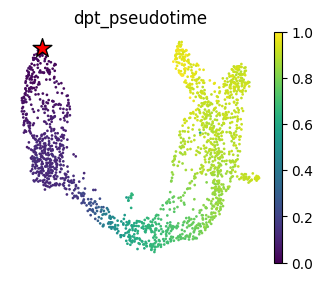

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'clusters', n_clusters = 8
[cluster=Ductal] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.183), n_jobs = 10.
[cluster=Ngn3 low EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 6 (factor = 0.532), n_jobs = 10.
[cluster=Ngn3 high EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 7 (factor = 0.635), n_jobs = 10.
[cluster=Pre-endocrine] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.232), n_jobs = 10.
[cluster=Beta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.15), n_jobs = 10.
[cluster=Alpha] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.33), n_jobs = 10.
[cluster=Delta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0432), n_jobs = 10.
[cluster=Epsilon] Fitting NB GLMGam for 2000 genes (cen

  0%|          | 0/1848 [00:00<?, ?cells/s]

computing velocity graph
finished.


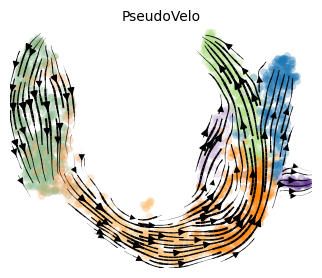

computing velocity embedding
finished.


  0%|          | 0/1848 [00:00<?, ?cell/s]

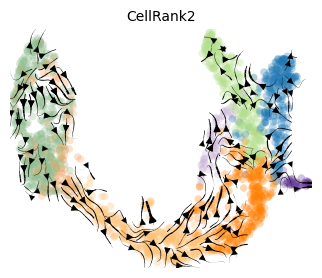

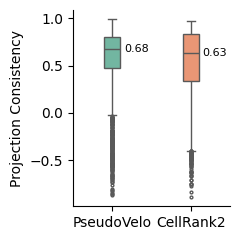

dpt_pseudotime - pv accuracy: 0.61388826
dpt_pseudotime - cr2 accuracy: 0.5386234807700698


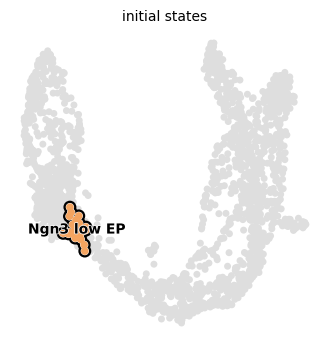

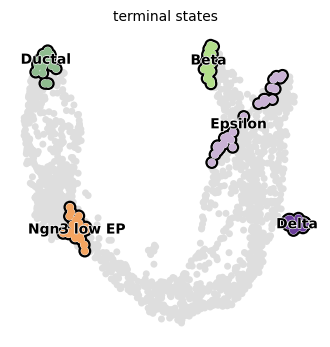

  0%|          | 0/1848 [00:00<?, ?cell/s]

  0%|          | 0/1848 [00:00<?, ?cell/s]

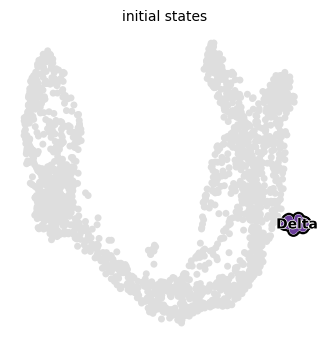

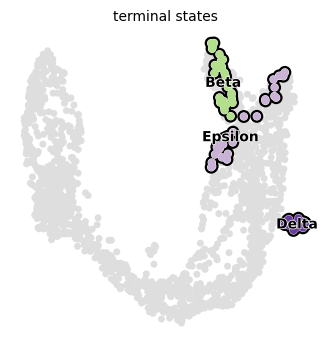

In [8]:
# 2.2 Cell Subsampling Test
print("\n--- Running Robustness: Cell Subsampling ---")
adata_rob_cell = load_and_preprocess_data(subsample_cells=True)
root_idx = find_root_index(adata_rob_cell, "clusters", "Ductal")
_ = run_eval_pipeline(adata_rob_cell, root_idx=root_idx, cluster_key="clusters")


--- Running Robustness: Gene Subsampling ---


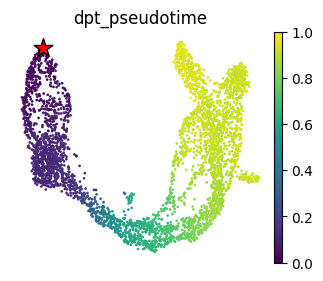

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'clusters', n_clusters = 8
[cluster=Ductal] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.17), n_jobs = 10.
[cluster=Ngn3 low EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 5 (factor = 0.5), n_jobs = 10.
[cluster=Ngn3 high EP] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 7 (factor = 0.664), n_jobs = 10.
[cluster=Pre-endocrine] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.287), n_jobs = 10.
[cluster=Beta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.138), n_jobs = 10.
[cluster=Alpha] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.109), n_jobs = 10.
[cluster=Delta] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0643), n_jobs = 10.
[cluster=Epsilon] Fitting NB GLMGam for 2000 genes (cent

  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


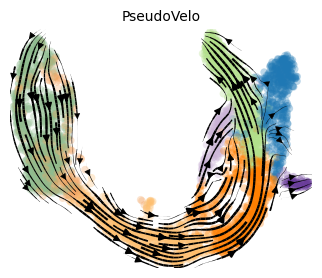

computing velocity embedding
finished.


  0%|          | 0/3696 [00:00<?, ?cell/s]

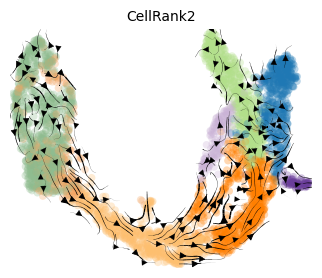

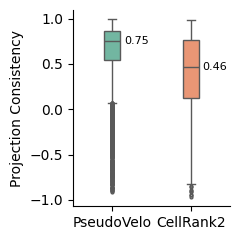

dpt_pseudotime - pv accuracy: 0.61264765
dpt_pseudotime - cr2 accuracy: 0.5262674282606493


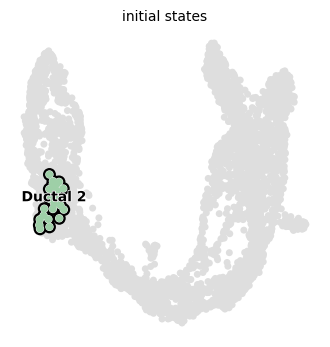

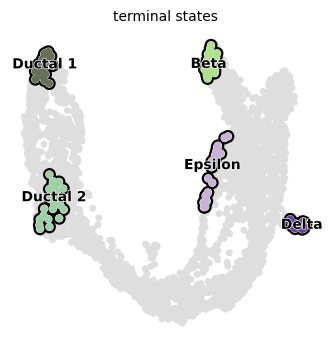

  0%|          | 0/3696 [00:00<?, ?cell/s]

  0%|          | 0/3696 [00:00<?, ?cell/s]

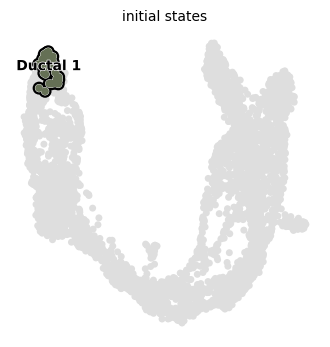

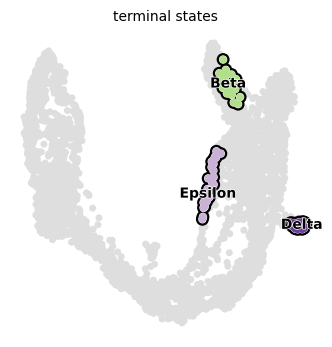

In [7]:
# 2.3 Gene Subsampling Test
print("\n--- Running Robustness: Gene Subsampling ---")
adata_rob_gene = load_and_preprocess_data(subsample_genes=True)
root_idx = find_root_index(adata_rob_gene, "clusters", "Ductal")
_ = run_eval_pipeline(adata_rob_gene, root_idx=root_idx, cluster_key="clusters")